# RetentionAI — 10. Thompson Sampling for Offer Selection (Stage 11)

**The question this stage answers: once we know WHO to call (Stages 7-10), WHICH offer do we actually give them?** Discount vs. technician visit vs. no offer/control — we don't know upfront which works best, and real churn outcomes take 30-90+ days to observe, so live A/B routing has no fast reward signal to learn from (consistent with ADR-000's broader caution against reaching for advanced techniques before they're justified, though this specific tradeoff -- live routing vs. offline replay -- is reasoned through fresh here, not something ADR-000 addressed directly). This is evaluated entirely through **offline replay** (Li et al. 2011) against a logged history — never live traffic.

**Honest limitation up front:** this dataset has no real logged intervention/outcome data at all — no column records what offer, if any, a customer received historically.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.bandit.thompson import ThompsonSamplingBandit, simulate_historical_log, offline_replay_evaluation

rng = np.random.default_rng(42)

## Build the synthetic historical log

Three arms, tied to ADR-001's actual intervention set: a price-based offer (`discount`), a service-based fix (`technician`), and no intervention at all (`control`) as the honest baseline. True success rates are HIDDEN from the bandit — it only ever sees `(arm, reward)` pairs, never these numbers directly. Arms are assigned **uniform random** in the log — required for the replay method's unbiasedness (Decision Point in ADR-012), not an arbitrary choice.

In [2]:
true_success_rates = {"discount": 0.65, "technician": 0.45, "control": 0.30}
log = simulate_historical_log(30000, list(true_success_rates.keys()), true_success_rates, rng)

print(log["arm"].value_counts())
print()
print("Observed retention rate per arm in the raw log (sanity check only -- bandit never sees this directly):")
print(log.groupby("arm")["reward"].mean())

arm
discount      10049
technician    10028
control        9923
Name: count, dtype: int64

Observed retention rate per arm in the raw log (sanity check only -- bandit never sees this directly):
arm
control       0.306157
discount      0.647229
technician    0.458117
Name: reward, dtype: float64


## Run offline replay evaluation

For each logged event: ask the bandit's CURRENT policy which arm it would pick. If that matches the arm the log actually used, count it (update the bandit, record the outcome). If not, skip — we don't know what would have happened with a different arm for that customer, so it can't be used. This is what makes the evaluation unbiased despite never running live.

In [3]:
bandit = ThompsonSamplingBandit(list(true_success_rates.keys()))
match_rate, history = offline_replay_evaluation(bandit, log, rng)

print(f"Match rate: {match_rate:.3f} ({int(match_rate * len(log))} of {len(log)} logged events actually used)")
print(f"Final posterior means: {bandit.posterior_means()}")
print(f"True success rates:    {true_success_rates}")

Match rate: 0.335 (10036 of 30000 logged events actually used)
Final posterior means: {'discount': 0.6472647264726472, 'technician': 0.36363636363636365, 'control': 0.1}
True success rates:    {'discount': 0.65, 'technician': 0.45, 'control': 0.3}


## The real finding: the best arm converges tightly — the others don't, and that's not a bug

Look at how many matched (usable) observations each arm actually ended up with.

In [4]:
n_obs = {a: bandit.alpha[a] + bandit.beta[a] - 2 for a in true_success_rates}  # minus the Beta(1,1) prior
print("Matched observations per arm:", n_obs)
print()
print("This is the replay method's known sample-inefficiency cost: once the bandit gets confident")
print("'discount' is best, it stops MATCHING the log whenever the historical random assignment was")
print("'technician' or 'control' -- so those arms stop accumulating usable data, even though the raw")
print("log had roughly equal counts of all three (~10,000 each).")

Matched observations per arm: {'discount': 9997.0, 'technician': 31.0, 'control': 8.0}

This is the replay method's known sample-inefficiency cost: once the bandit gets confident
'discount' is best, it stops MATCHING the log whenever the historical random assignment was
'technician' or 'control' -- so those arms stop accumulating usable data, even though the raw
log had roughly equal counts of all three (~10,000 each).


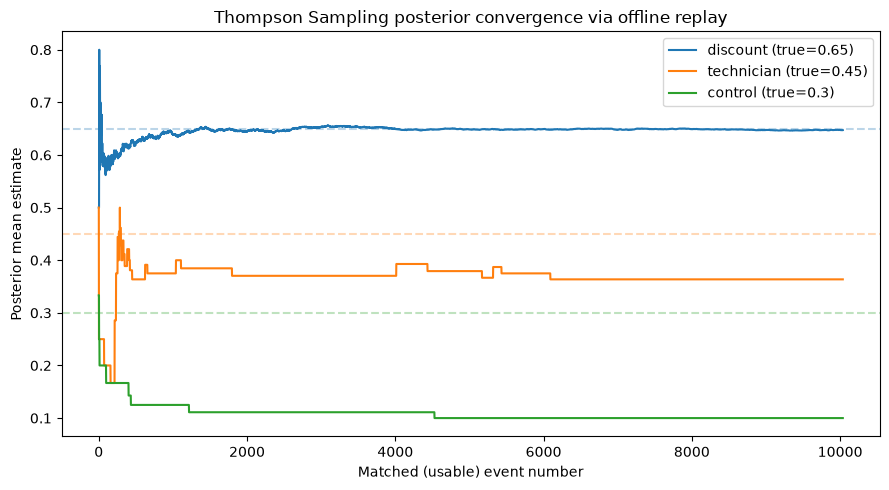

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for arm in true_success_rates:
    ax.plot(history["event"], history[arm], label=f"{arm} (true={true_success_rates[arm]})")
    ax.axhline(true_success_rates[arm], linestyle="--", alpha=0.3, color=ax.lines[-1].get_color())
ax.set_xlabel("Matched (usable) event number")
ax.set_ylabel("Posterior mean estimate")
ax.set_title("Thompson Sampling posterior convergence via offline replay")
ax.legend()
plt.tight_layout()
plt.show()

## Stage 11 summary

- Ranking recovered correctly: `discount > technician > control`, matching the hidden true rates.
- The **best** arm (`discount`) converges tightly to its true rate (~9,000+ matched observations by the end) — exactly what a good bandit should do, since maximizing reward means *exploiting* the best arm as fast as the evidence allows.
- The **weaker** arms end up with far fewer matched observations (tens, not thousands) — not a flaw in this implementation, but the documented cost of the replay evaluation method itself: it can only learn from events where its current policy happens to agree with the historical random assignment, and that agreement rate drops for arms the bandit has already learned to avoid.
- Practical implication for a real deployment: replay evaluation tells you reliably whether your *best* arm is well-identified, but gives comparatively weak evidence about precisely how bad the losing arms are — good enough for "should we route more traffic to discount," not precise enough for "exactly how much worse is technician than discount."

**Caveat, louder than usual this time:** the historical log itself is entirely synthetic — this project has no real intervention/outcome data, the same honest gap ADR-002 already flagged for uplift modeling. If real logged intervention data becomes available (e.g., from an actual pilot with logged random assignment), this exact code runs unchanged against it.

Next: Stage 12a — counterfactual explanations ("why did the model flag this specific customer"), before the production API and deployment layer (Stages 12b/12c) that follow it.